In [1]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
from data_statistic1 import calcular_medidas_descritivas, gerar_painel_boxplot,analisar_dispersao_dados, gerar_grafico_pizza, analisar_assimetria_dados, analisar_curtose_dados

### Objetivo

Com o intuito de analisar o desempenho financeiro do e-commerce Olist entre 2016 e 2018, procedeu-se inicialmente à limpeza da base de dados. Foram desconsiderados todos os pedidos com status de cancelamento ou indisponibilidade, permitindo uma visão precisa do valor bruto de vendas efetivamente processado pela plataforma. Esta filtragem é essencial para que a análise de outliers e a identificação dos produtos que sustentam a receita reflitam transações reais de mercado.

Além disso, foi identificado pedidos com status de entregue, porém sem valor monetário atribuído tanto ao preço do pedido como ao valor do frete. Esses registros foram classificados como itens de bonificação e foi decidido remover esses registros do cálculo.

Tabela com valores totais dos pedidos do olist ecommerce



,order_id,order_status,valor_total_pedido,valor_total_frete,categoria,nota_review
1,53cdb2fc8bc7dce0b6741e2150273451,delivered,118.7,22.76,perfumaria,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,delivered,159.9,19.22,automotivo,5.0
3,949d5b44dbf5de918fe9c16f97b45f8a,delivered,45.0,27.20,pet_shop,5.0
4,ad21c59c0840e6cb83a9ceb5573f8159,delivered,19.9,8.72,papelaria,5.0
5,a4591c265e18cb1dcee52889e2d8acc3,delivered,147.9,27.36,automotivo,4.0


Medidas descritivas calculadas com sucesso! 
Painel salvo em boxplot_valor_pedidos.png


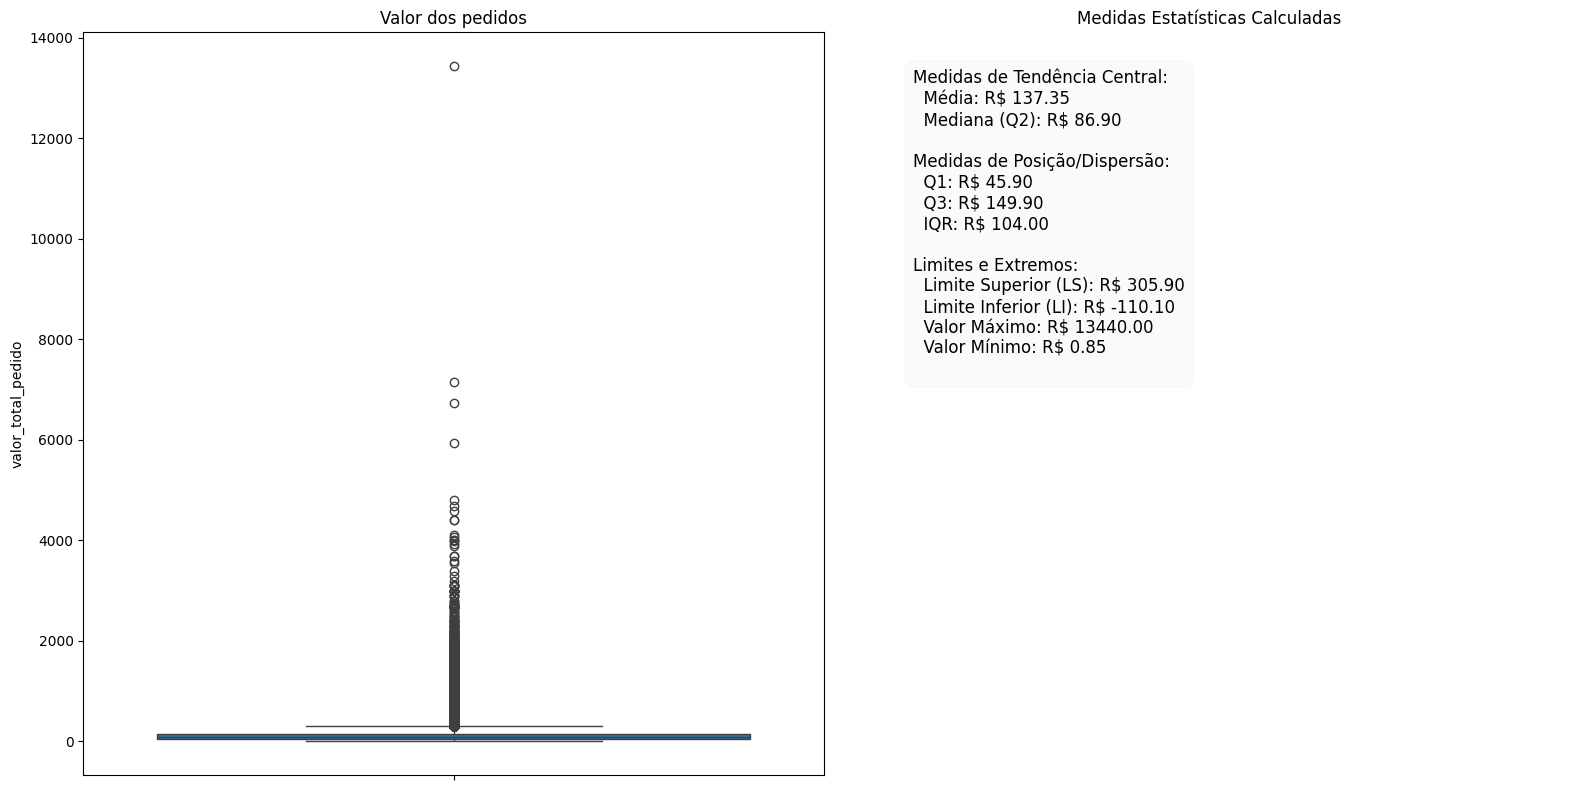

In [2]:
# Entrada de dados com o csv tratado - apenas com os pedidos com status de entregue.
#df_faturamento = pd.read_csv('../../dados_usados/dados_tratados_olist/olist_pedidos_faturamento_real.csv')
inicial = pd.read_csv('olist_analise_mestra_pedidos.csv')
df_validos = inicial[(inicial['valor_total_pedido'] > 0) & (inicial['order_status'] == 'delivered')]

print("Tabela com valores totais dos pedidos do olist ecommerce\n")
display(df_validos.head(5))

# Recebe os valores dos pedidos
valor_pedidos = df_validos['valor_total_pedido']

medidas_descritivas = calcular_medidas_descritivas(valor_pedidos)
gerar_painel_boxplot(valor_pedidos, medidas_descritivas, 'Valor dos pedidos', 'boxplot_valor_pedidos.png')



In [3]:
# Dispersão dos dados
analisar_dispersao_dados(valor_pedidos, medidas_descritivas)

# Calcular assimetria
assimetria = analisar_assimetria_dados(medidas_descritivas)

# Calcular curtose
curtose = analisar_curtose_dados(medidas_descritivas)


Conclusão da Dispersão: Alta dispersão dos dados em relação à média.

Conclusão da Assimetria: Positiva. A cauda se estende para a direita (valores maiores). Média > Mediana.

Conclusão da Curtose: Leptocúrtica. Dados extremamente concentrados no centro e caudas pesadas. Outiliers muito comuns.


### Histograma de preços dos pedidos

Grafico histograma salvo em histograma_preco_pedidos.png


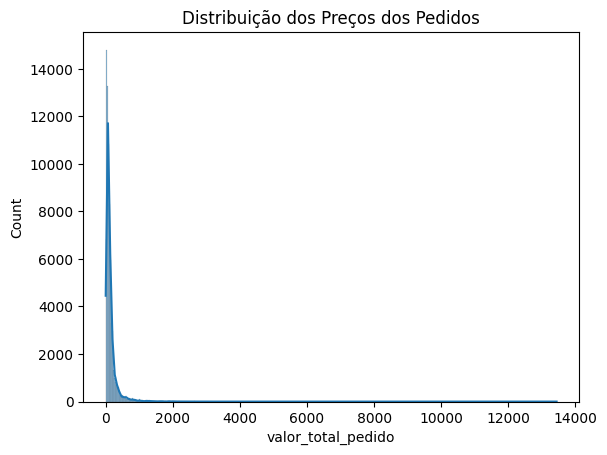

In [4]:
# Gerar Histograma com os preços dos pedidos

sns.histplot(df_validos['valor_total_pedido'], kde=True) # kde=True adiciona a curva de densidade, traduzindo seria "Kernel Density Estimate"
plt.title('Distribuição dos Preços dos Pedidos')
plt.savefig('histograma_preco_pedidos.png')
print(f"Grafico histograma salvo em {'histograma_preco_pedidos.png'}")
plt.show()  


Os valores dos pedidos mais caros(outliers superiores) estão influenciando na média dos valores, ou seja, está deslocando a média para cima e para longe do comportamento da maioria dos consumidores. Isso confirma que uma pequena parcela pedidos 'premium' é responsável por elevar o patamar financeiro da empresa.

Enquanto a média é influenciada pelos pedidos caros, a mediana nos mostra o valor real que divide o público ao meio. A grande distância entre a média e a mediana é a prova estatística da influência desses outliers no faturamento.

### Análise do faturamento bruto 

Para entender o faturamento da empresa, precisamos entender qual o faturamento dos pedidos normais do ecommerce e o faturamento dos pedidos de alto valor.



In [5]:
# Mostrar os outliers dos pedidos
# Como o limite inferior dos dados deu negativo, vamos focar nos outliers superiores.
limite_superior = medidas_descritivas['limite_superior']
outliers_superiores = df_validos[df_validos['valor_total_pedido'] > limite_superior ]
pedidos_normais = df_validos[df_validos['valor_total_pedido'] < limite_superior]

faturamento_total = df_validos['valor_total_pedido'].sum()
faturamento_outliers_superiores = outliers_superiores['valor_total_pedido'].sum()
faturamento_normais = pedidos_normais['valor_total_pedido'].sum()


print(f"O faturamento total dos pedidos: R${faturamento_total.round(2)}")
print(f"O faturamento dos outliers superiores (Pedidos 'premium'): R${faturamento_outliers_superiores}")
print(f"O faturamento dos pedidos normais: R${faturamento_normais.round(2)}")

parcela_outliers = (faturamento_outliers_superiores / faturamento_total) * 100 
print(f"\nOs outliers representam {parcela_outliers.round(2)}% do faturamento do ecommerce.")


qtd_total_pedidos = len(df_validos)
qtd_outliers_superiores = len(outliers_superiores)

print(f"\nQuantidade Total de pedidos = {qtd_total_pedidos} \nQuantidade outliers superiores = {qtd_outliers_superiores}")
parcela_qtd_outliers = ((qtd_outliers_superiores / qtd_total_pedidos) * 100 )
print(f"\nOs outliers representam {parcela_qtd_outliers:.2f}% do total de pedidos.") # Não estou conseguindo usar o round(2)



O faturamento total dos pedidos: R$11764471.35
O faturamento dos outliers superiores (Pedidos 'premium'): R$4314763.99
O faturamento dos pedidos normais: R$7449401.46

Os outliers representam 36.68% do faturamento do ecommerce.

Quantidade Total de pedidos = 85652 
Quantidade outliers superiores = 6824

Os outliers representam 7.97% do total de pedidos.


A análise de distribuição de renda revela uma dependência estratégica do segmento 'Premium'. Identificou-se que os outliers (pedidos acima de R$ 305,90) representam apenas 8% do volume total de transações, contudo, são responsáveis por 36,68% do faturamento bruto da empresa.

Essa desproporção demonstra que os pedidos de alto ticket são os principais pilares da saúde financeira do e-commerce. Uma eventual redução nesse nicho comprometeria severamente a sustentabilidade da operação, uma vez que a receita gerada por eles subsidia os custos fixos que os pedidos de menor valor, por si só, teriam dificuldade em cobrir.



In [6]:
inicial = pd.read_csv('../Relatorios/olist_analise_mestra_pedidos.csv') # Entrada de dados 
df_validos = inicial[(inicial['valor_total_pedido'] > 0) & (inicial['order_status'] == 'delivered')]


# 2. Definir o segmento
limite_olist = 305.90
df_validos['segmento'] = df_validos['valor_total_pedido'].apply(lambda x: 'Premium' if x > limite_olist else 'Normal')

# 3. Gerar o resumo
resumo_df_validos = df_validos.groupby('segmento').agg(
    qtd_pedidos=('order_id', 'count'),
    faturamento=('valor_total_pedido', 'sum')
).reset_index()

# 4. Calcular porcentagens
total_pedidos = resumo_df_validos['qtd_pedidos'].sum()
total_faturamento = resumo_df_validos['faturamento'].sum()

resumo_df_validos['percentual_pedidos'] = (resumo_df_validos['qtd_pedidos'] / total_pedidos) * 100
resumo_df_validos['percentual_faturamento'] = (resumo_df_validos['faturamento'] / total_faturamento) * 100

resumo_df_validos.to_csv('pb_resumo_olist_tema1.csv', index=False)
display(resumo_df_validos)




,segmento,qtd_pedidos,faturamento,percentual_pedidos,percentual_faturamento
0,Normal,78828,7449707.36,92.032877,63.323775
1,Premium,6824,4314763.99,7.967123,36.676225


### Gráfico em pizza da relação de vendas 

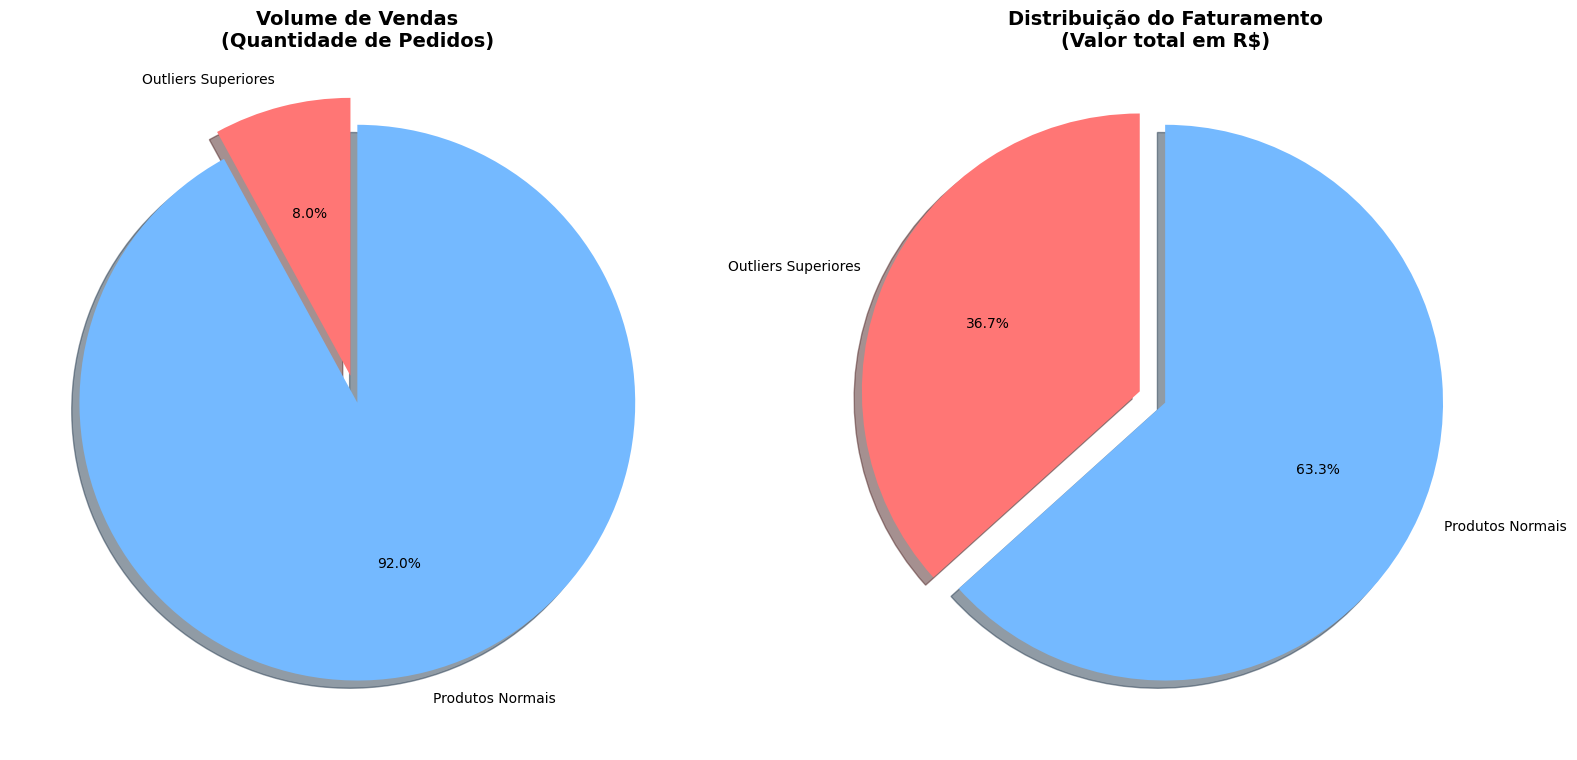

In [7]:
gerar_grafico_pizza(faturamento_outliers_superiores, faturamento_total,qtd_outliers_superiores,qtd_total_pedidos)

### Análise de faturamento por categoria
Para aprofundar a análise, realizou-se um enriquecimento de dados cruzando o faturamento dos pedidos com as categorias de produtos originais da Olist. Isso permitiu identificar quais nichos de mercado são os principais responsáveis por gerar os outliers de alto valor que sustentam a receita bruta da plataforma.


A análise de faturamento por categoria foi realizada com base na categoria dominante do pedido.

In [8]:
faturamento_categorias = df_validos.groupby('categoria').agg({
    'valor_total_pedido' : 'sum',
    'nota_review' : 'mean'

}).sort_values(by='valor_total_pedido', ascending=False)

display(faturamento_categorias)
faturamento_total_categorias = faturamento_categorias['valor_total_pedido'].sum()
print(faturamento_total_categorias)

,valor_total_pedido,nota_review
categoria,,
beleza_saude,1089515.51,4.227005
relogios_presentes,1051146.00,4.125822
cama_mesa_banho,911789.39,4.004706
esporte_lazer,844095.06,4.238572
informatica_acessorios,777544.12,4.076400
...,...,...
pc_gamer,1046.97,3.600000
casa_conforto_2,695.77,3.833333
cds_dvds_musicais,665.00,4.636364


11620091.35


In [9]:
faturamento_categorias_outliers = outliers_superiores.groupby('categoria').agg({
    'valor_total_pedido' : 'sum',
    'nota_review' : 'mean'
}).sort_values(by='valor_total_pedido', ascending=False)

print("Faturamento por categoria dos produtos 'premium'")
display(faturamento_categorias_outliers)

Faturamento por categoria dos produtos 'premium'


,valor_total_pedido,nota_review
categoria,,
relogios_presentes,530078.60,4.175097
beleza_saude,497524.42,4.210305
informatica_acessorios,258563.26,3.862338
automotivo,236090.22,3.804533
esporte_lazer,234073.42,3.932817
...,...,...
livros_tecnicos,713.93,5.000000
artigos_de_natal,701.40,NaN
pc_gamer,438.00,5.000000


A análise comparativa entre o faturamento total e o faturamento 'Premium' revelou uma concentração crítica nas categorias de Beleza & Saúde e Relógios & Presentes. Identificou-se que aproximadamente 50% da receita dessas categorias é derivada diretamente de pedidos outliers.

As duas categorias compartilham o mesmo perfil de consumo. 
- Quem compra um perfume caro (beleza_saude) muitas vezes é o mesmo cliente que investe em um acessório de luxo(relógios).
- O fato de os outliers representarem 50% do faturamento dessas categorias prova que o seu lucro vem de um grupo seleto que busca qualidade e marcas mais caras.

Isso quer dizer que esses produtos tem uma área destinada a clientes com um poder aquisitivo elevado. Então é evidente que precisamos pensar em maneiras de manter/expandir as vendas desses produtos. Recomenda-se a utilização de promoções cruzadas entre os dois segmentos, aproveitando a similaridade de perfil do consumidor, essa medida pode ser uma boa estratégia de marketing para o e-commerce fidelizar o cliente de alto valor e aumentar as vendas.




### Análise de cancelamentos dos pedidos

In [10]:
# Preciso pegar os pedidos com valor > 0.
inicial['segmento'] = inicial['valor_total_pedido'].apply(lambda x: 'Premium' if x > limite_olist else 'Normal')


# df com os pedidos cancelados por segmento
olist_cancelados = inicial[inicial['order_status'] == 'canceled'].groupby('segmento').agg(
    qtd_pedidos_cancelados = ('order_status', 'count'),    
).reset_index()

olist_cancelados['percentual_pedidos_cancelados'] = ((olist_cancelados['qtd_pedidos_cancelados'] / total_pedidos) * 100).round(2)

qtd_pedidos_normais = resumo_df_validos[resumo_df_validos['segmento'] == 'Normal']['qtd_pedidos'].iloc[0] # poderia usar values[]
qtd_pedidos_premium = resumo_df_validos[resumo_df_validos['segmento'] == 'Premium']['qtd_pedidos'].iloc[0]

# Dicionário para aplicar os valores totais de pedidos por segmento no df
mapa_quantidades = {
    'Normal': qtd_pedidos_normais,
    'Premium': qtd_pedidos_premium
}

olist_cancelados['qtd_pedidos_total_segmento'] = olist_cancelados['segmento'].map(mapa_quantidades)

# Mudar a ordem das colunas
nova_ordem = ['segmento', 'qtd_pedidos_total_segmento', 'qtd_pedidos_cancelados', 'percentual_pedidos_cancelados']

olist_cancelados = olist_cancelados[nova_ordem]

display(olist_cancelados)

,segmento,qtd_pedidos_total_segmento,qtd_pedidos_cancelados,percentual_pedidos_cancelados
0,Normal,78828,571,0.67
1,Premium,6824,54,0.06


A quantidade de pedidos cancelados nesse dataset do olist é de 0.67% para pedidos normais e 0.06% para pedidos premium, ou seja, números que não impactam de forma a depreciar financeiramente o funcionamento do ecommerce.
* Principalmente no segmento premium, a taxa sugere que o público está decidido na compra, quase não há desistência após compra.
> A empresa não precisa direcionar o foco com os pedidos cancelados e pode focar no **marketing**, para atrair e aumentar o público de ambos os segmentos.

## Sazonalidade do faturamento

In [11]:
data_olist = pd.read_csv("E:\\Varias Coisas\\Estudo\\analista_senac\\UC2_atualizado\\Projeto\\dados_usados\\dados_tratados_olist\\order_limpo\\order_consolidado.csv") 

df_orders_datas = data_olist[['order_id', 'order_purchase_timestamp']].rename(
    columns={'order_purchase_timestamp': 'DATA_REF'}
)

df_orders_datas['DATA_REF'] = pd.to_datetime(df_orders_datas['DATA_REF'])

# 1. Remover a DATA_REF do df_validos caso ela já esteja lá (evita o erro de duplicata)
if 'DATA_REF' in df_validos.columns:
    df_validos = df_validos.drop(columns=['DATA_REF'])

# 2. Agora o merge vai funcionar perfeitamente
df_validos = df_validos.merge(df_orders_datas, on='order_id', how='left')

# 3. Truncar para o mês (como fizemos antes)
df_validos['DATA_REF_MENSAL'] = df_validos['DATA_REF'].dt.to_period('M').dt.to_timestamp()

# 2. AGRUPAR pela nova coluna mensal
comparativo_mensal_olist = (
    df_validos.groupby(['DATA_REF_MENSAL', 'segmento'])
    .agg(faturamento=('valor_total_pedido', 'sum'))
    .unstack(fill_value=0) # Esse comando transforma as linhas 'Normal/Premium' em colunas
    .reset_index()
)

comparativo_mensal_olist.columns = ['DATA_REF_MENSAL', 'faturamento_mensal_normal', 'faturamento_mensal_premium']

# 4. Ordenar para o gráfico de linha fazer sentido (passado para o futuro)
comparativo_mensal_olist = comparativo_mensal_olist.sort_values('DATA_REF_MENSAL')


display(comparativo_mensal_olist)




,DATA_REF_MENSAL,faturamento_mensal_normal,faturamento_mensal_premium
0,2016-09-01,134.97,0.00
1,2016-10-01,20572.54,16452.73
2,2016-12-01,10.90,0.00
3,2017-01-01,52835.30,47643.03
4,2017-02-01,117646.85,84661.14
5,2017-03-01,190477.82,130303.09
6,2017-04-01,177425.11,127320.14
7,2017-05-01,269905.03,163848.92
8,2017-06-01,232229.36,144079.09
9,2017-07-01,294512.52,133309.31


Ao analisar o ciclo mensal, vemos que a Olist opera em dois ritmos: o Segmento Normal é o coração da estabilidade e explode na Black Friday, enquanto o Segmento Premium mostra picos estratégicos em datas como o Dia das Mães, provando que itens de alto valor têm um apelo emocional e sazonal diferente do que itens de baixo custo.